In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('../data/insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
data.duplicated().sum()

np.int64(1)

In [5]:
data[data.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [6]:
data.drop_duplicates(inplace=True)

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


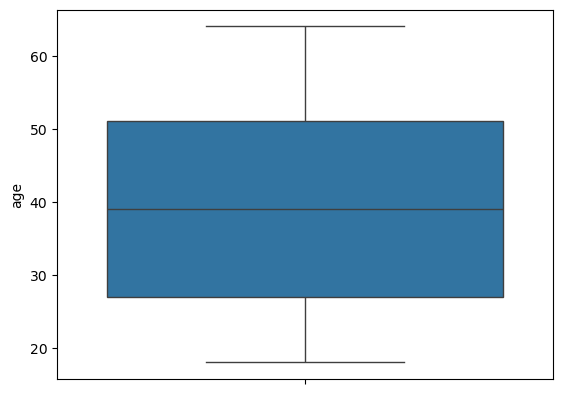

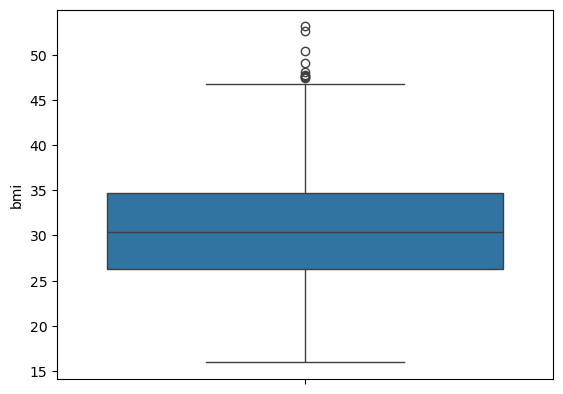

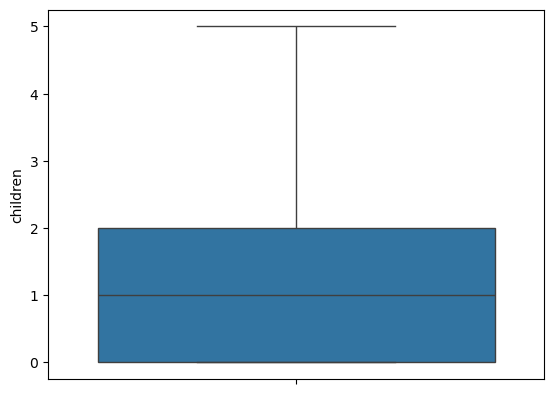

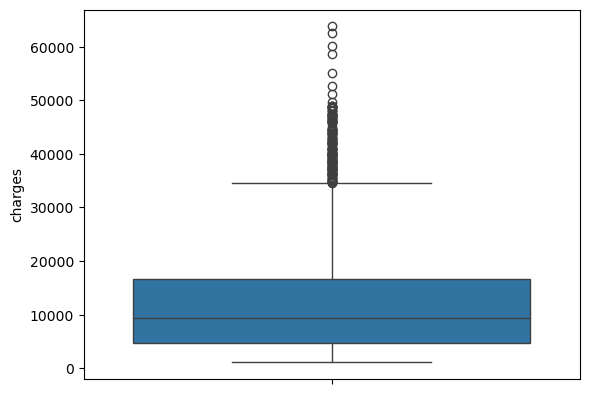

In [9]:
for col in data.columns:
    if data[col].dtype!='object':
        sns.boxplot(data[col])
        plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
temp={}
for col in data.columns:
    if data[col].dtype=='object':
        LE=LabelEncoder()
        data[col]=LE.fit_transform(data[col])

        temp[col]=dict(zip(LE.classes_,LE.transform(LE.classes_)))
        

In [12]:
print(temp)

{'sex': {'female': np.int64(0), 'male': np.int64(1)}, 'smoker': {'no': np.int64(0), 'yes': np.int64(1)}, 'region': {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}}


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   int64  
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   int64  
 5   region    1337 non-null   int64  
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 83.6 KB


In [14]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
data_pre=data.copy()

tempBMI=data_pre.bmi
tempBMI=tempBMI.values.reshape(-1,1)
data_pre['bmi']=sc.fit_transform(tempBMI)


tempage=data_pre.age
tempage=tempage.values.reshape(-1,1)
data_pre['age']=sc.fit_transform(tempage)


tempcharges=data_pre.charges
tempcharges=tempcharges.values.reshape(-1,1)
data_pre['charges']=sc.fit_transform(tempcharges)

In [15]:
data_pre.head()

,age,sex,bmi,children,smoker,region,charges
0,-1.440418,0,-0.453160,0,1,3,0.297857
1,-1.511647,1,0.509422,1,0,2,-0.954381
2,-0.799350,1,0.383155,3,0,2,-0.729373
3,-0.443201,1,-1.305052,0,0,1,0.719104
4,-0.514431,1,-0.292456,0,0,1,-0.777499


In [16]:
x=data_pre.drop('charges',axis=1)
y=data_pre['charges']

In [17]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.80)

LINEAR REGRESSION MODEL


In [18]:
%%time
from sklearn.linear_model import LinearRegression
linear_model=LinearRegression()
linear_model.fit(x_train,y_train)

CPU times: total: 78.1 ms
Wall time: 93.4 ms


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
import pickle

def save_model(model,model_name):
    path='../ML_models/'+model_name+'.pkl'
    with open(path,'wb') as file:
        pickle.dump(model,file)

def get_model(model_name):
    path='../ML_models/'+model_name+'.pkl'
    with open(path,'rb') as file:
        return pickle.load(file)

In [20]:
save_model(linear_model,'Linear_Model')

In [21]:
lr_model=get_model('Linear_model')

NameError: name 'Linear_model' is not defined

In [ ]:
prediction=lr_model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,prediction)*100

Support Vector Machine Model


In [ ]:
x=x.to_numpy()
y=y.to_numpy().reshape(-1,1)

In [ ]:
x_train_c,x_test_c,y_train_c,y_test_c=train_test_split(x,y,train_size=0.75)
x_train_scaled=sc.fit_transform(x_train_c)
x_test_scaled=sc.fit_transform(x_test_c)
y_train_scaled=sc.fit_transform(y_train_c)
y_test_scaled=sc.fit_transform(y_test_c)

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV
svr=SVR()

In [ ]:
%%time
parameters={
    'kernel':['rbf','sigmoid'],
    'gamma' : [0.001, 0.01, 0.1, 1, 'scale'],
    'tol' : [0.0001],
    'C': [0.001, 0.01, 0.1, 1, 10, 100] }
svr_grid = GridSearchCV(estimator=svr, param_grid=parameters, cv=10, verbose=4, n_jobs=-1)
svr_grid.fit(x_train_scaled, y_train_scaled.ravel())

In [ ]:
svr=SVR(C=1, gamma=0.1, tol=0.0001)
svr.fit(x_train_scaled,y_train_scaled.ravel())
print(svr_grid.best_estimator_)
print(svr_grid.best_score_)

In [ ]:
save_model(svr,'sup_vect_machine')

In [ ]:
svm_model=get_model('sup_vect_machine')

In [ ]:
prediction=svm.predict(x_test_scaled)
r2_score(y_test_scaled,prediction)*100